In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
from empiricaldist import Pmf

from utils import make_binomial, decorate

sns.set_style('darkgrid')

## 6.1 Odds

In [3]:
def odds(p):
    return p / (1-p)

def prob(o):
    return o / (o+1)

## 6.4 Addends

In [7]:
def make_die(sides):
    outcomes = np.arange(1, sides+1)
    die = Pmf(1 / sides, outcomes)
    return die

## 6.6 The Forward Problem

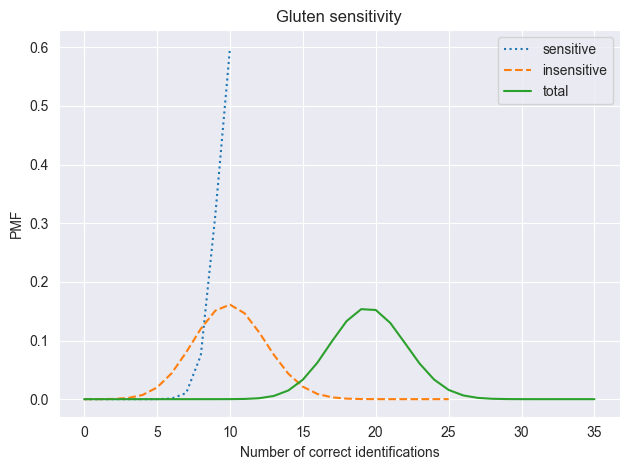

In [20]:
num_subject = 35
num_sensitive = 10
num_insensitive = num_subject - num_sensitive

dist_sensitive_correct = make_binomial(num_sensitive, 0.95)
dist_insensitive_correct = make_binomial(num_insensitive, 0.40)
dist_total_correct = Pmf.add_dist(dist_sensitive_correct, dist_insensitive_correct)

dist_sensitive_correct.plot(label='sensitive', ls=':')
dist_insensitive_correct.plot(label='insensitive', ls='--')
dist_total_correct.plot(label='total')
decorate(
    xlabel='Number of correct identifications',
    ylabel='PMF',
    title='Gluten sensitivity'
)

## 6.7 The Inverse Problem

In [ ]:
table = pd.DataFrame()
for num_sensitive in range(0, num_subject + 1):
    num_insensitive = num_subject - num_sensitive
    dist_sensitive_correct = make_binomial(num_sensitive, 0.95)
    dist_insensitive_correct = make_binomial(num_insensitive, 0.4)
    dist_total_correct = Pmf.add_dist(
        dist_sensitive_correct, 
        dist_insensitive_correct
    )
    table[num_sensitive] = dist_total_correct

# columns are the number of sensitive subjects
# rows are the number of correct identifications
table.head(3)

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,1.719071e-08,1.432559e-09,1.193799e-10,9.948326e-12,8.290272e-13,6.908560e-14,5.757133e-15,4.797611e-16,3.998009e-17,3.331674e-18,...,1.501694e-36,1.251411e-37,1.042843e-38,8.690357e-40,7.241964e-41,6.034970e-42,5.029142e-43,4.190952e-44,3.492460e-45,2.910383e-46
1,4.011165e-07,5.968996e-08,7.162795e-09,7.792856e-10,8.013930e-11,7.944844e-12,7.676178e-13,7.276377e-14,6.796616e-15,6.274653e-16,...,7.508469e-34,6.486483e-35,5.596590e-36,4.823148e-37,4.152060e-38,3.570691e-39,3.067777e-40,2.633315e-41,2.258457e-42,1.935405e-43
2,4.545987e-06,9.741401e-07,1.709122e-07,2.506426e-08,3.269131e-09,3.940182e-10,4.490244e-11,4.908756e-12,5.197412e-13,5.365476e-14,...,1.806613e-31,1.620070e-32,1.449030e-33,1.292922e-34,1.151034e-35,1.022555e-36,9.066202e-38,8.023344e-39,7.088005e-40,6.251357e-41


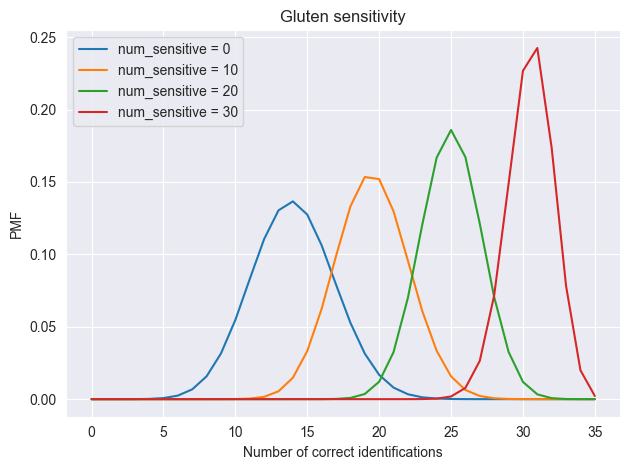

In [25]:
table[0].plot(label='num_sensitive = 0')
table[10].plot(label='num_sensitive = 10')
table[20].plot(label='num_sensitive = 20')
table[30].plot(label='num_sensitive = 30')

decorate(
    xlabel='Number of correct identifications',
    ylabel='PMF',
    title='Gluten sensitivity'
)

Most likely number of sensitive subjects with 12 correct: 0
Most likely number of sensitive subjects with 20 correct: 11


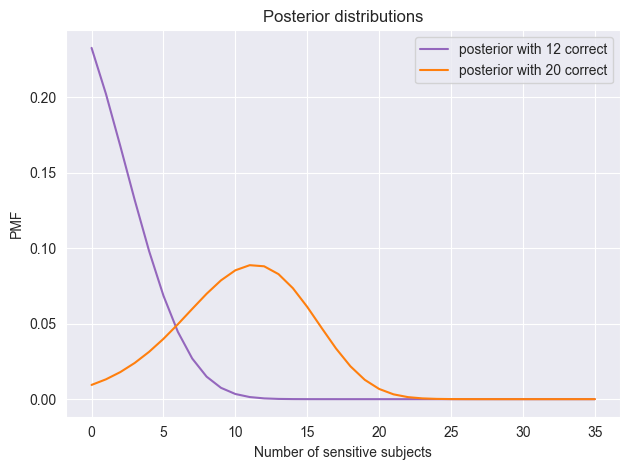

In [ ]:
hypos = np.arange(num_subject + 1)
prior = Pmf(1 / len(hypos), hypos)

# seeing 12 correct identifications
likelihood_1 = table.loc[12]
posterior1 = prior * likelihood_1
posterior1.normalize()

# seeing 20 correct identifications
likelihood_2 = table.loc[20]
posterior2 = prior * likelihood_2
posterior2.normalize()

# plot the two posteriors
posterior1.plot(label='posterior with 12 correct', color='C4')
posterior2.plot(label='posterior with 20 correct', color='C1')
decorate(
    xlabel='Number of sensitive subjects',
    ylabel='PMF',
    title='Posterior distributions'
)

print(f"Most likely number of sensitive subjects with 12 correct: {posterior1.max_prob()}")
print(f"Most likely number of sensitive subjects with 20 correct: {posterior2.max_prob()}")

## 6.9 Exercises
### 6.9.2 Exercise 2

In [4]:
prior_odds = odds(0.1)
posterior_odds = prior_odds * 2 * 2 * 2
prob(posterior_odds)

0.4705882352941177

### 6.9.3 Exercise 3

In [5]:
prob(odds(0.14) * 25)

0.8027522935779816

### 6.9.4 Exercise 4

In [ ]:
goblin_health = make_die(6).add_dist(make_die(6))

# goblin has at least 4 health (it's still alive after a point 3 damage)
goblin_health.loc[[2, 3]] = 0
goblin_health.normalize()

dealt_damage = Pmf(index=[1, 2, 3, 4, 5, 6], data=[0, 0, 1, 0, 0, 0])
attack_dice = make_die(6)

goblin_remaining_health = goblin_health.sub_dist(dealt_damage).sub_dist(attack_dice)
print(goblin_remaining_health.prob_le(0))

0.4545454545454545
